# Analisis de reseñas de `miempresa`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

Si te falta alguna libreria, puedes instalarla con:

```bash
pip install datasets pandas numpy scikit-learn transformers torch
```

In [1]:
import re
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

c:\Users\noelm\Downloads\NoelMendezLisonDeepLearningEvolve\.envdl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [2]:
MAX_ROWS = None  # Ejemplo: 5000 para pruebas rapidas         
TARGET = "mindfulchef.com"
CAT = "Restaurants & Bars"
N_TOPICS = 8            
TOP_WORDS = 12         
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde Hugging Face y lo convertimos a DataFrame.

In [3]:
df = pd.read_csv("../Data/trustpilot-reviews-123k.csv")
df.head(15)

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5
5,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Excellent good quality products,Excellent good quality products. Found exactly...,5
6,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Worth the Money,Worth the MoneyA bit more expensive than I wou...,5
7,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,4th purchase of brilliant coat,"This is the 4th purchase, not because anything...",5
8,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,High quality,"Well, nothing else but just GREAT. In love wit...",5
9,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,I have had several of you items and…,I have had several of you items and each one i...,5


## 4) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

In [4]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

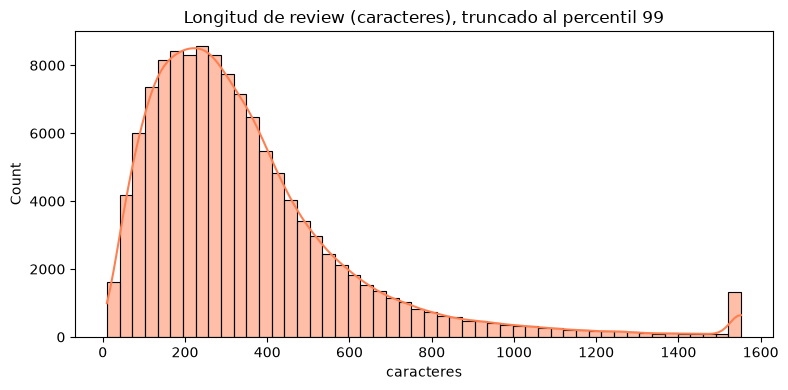

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [6]:
# ver que tipos de caracteres tenemos para construir la funcion de limpieza: hastags, emojis, urls, menciones, saltos de linea, signos de puntuacion, numeros, etc
# Contamos cuántas reseñas contienen cada tipo de elemento "sucio"
has_newlines = df['review'].astype(str).str.contains(r'\n').sum()
has_urls = df['review'].astype(str).str.contains(r'https?://\S+|www\.\S+').sum()
has_hashtags = df['review'].astype(str).str.contains(r'#\w+').sum()
has_mentions = df['review'].astype(str).str.contains(r'@\w+').sum()
has_numbers = df['review'].astype(str).str.contains(r'\d+').sum()

print("=== Análisis de Caracteres para la Función de Limpieza ===")
print(f"Reseñas con saltos de línea (\\n): {has_newlines} (¡Muy común!)")
print(f"Reseñas con URLs o enlaces web: {has_urls}")
print(f"Reseñas con Hashtags (#): {has_hashtags}")
print(f"Reseñas con Menciones (@): {has_mentions}")
print(f"Reseñas con Números (precios, fechas, etc.): {has_numbers}")

=== Análisis de Caracteres para la Función de Limpieza ===
Reseñas con saltos de línea (\n): 0 (¡Muy común!)
Reseñas con URLs o enlaces web: 5
Reseñas con Hashtags (#): 187
Reseñas con Menciones (@): 122
Reseñas con Números (precios, fechas, etc.): 50327


## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza



In [7]:
## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # 1. Convertimos a minúsculas
    text = text.lower()
    # 2. Eliminamos URLs completas (tanto http como www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 3. Eliminamos menciones (@) y hashtags (#)
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Eliminamos números por completo
    text = re.sub(r'\d+', '', text)
    # 5. Eliminamos signos de puntuación especiales (¡ ! ? ¿ , . / - etc) para dejar texto limpio
    text = re.sub(r'[^\w\s]', '', text)
    # 6. Eliminamos espacios múltiples extras que hayan quedado
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Probamos de nuevo la función con el texto de control
texto_prueba = "Excellent food! Delivered on time from www.mindfulchef.com #healthy 10/10"
print("Texto original:", texto_prueba)
print("Texto limpio:  ", clean_text(texto_prueba))

Texto original: Excellent food! Delivered on time from www.mindfulchef.com #healthy 10/10
Texto limpio:   excellent food delivered on time from


## 6) Filtrado del sector de la compañía objetivo

Filtramos por sector

In [8]:
## 6) Filtrado del sector de la compañía objetivo

# 1. Filtramos todas las empresas que pertenecen al mismo sector (Restaurants & Bars)
df_sector = df[df['category'] == CAT].copy()

# 2. Creamos el dataset exclusivo de NUESTRA empresa (TARGET -> mindfulchef.com)
df_target = df_sector[df_sector['company'] == TARGET].copy()

# 3. Creamos el dataset de la COMPETENCIA (todo el sector menos nuestra empresa)
df_comp = df_sector[df_sector['company'] != TARGET].copy()

print("=== Proceso de Filtrado y Limpieza Completado ===")
print(f"Reseñas totales en tu sector ({CAT}): {len(df_sector)}")
print(f"Reseñas de tu empresa ({TARGET}): {len(df_target)} (¡Deben ser 100!)")
print(f"Reseñas de la competencia para comparar: {len(df_comp)}")

=== Proceso de Filtrado y Limpieza Completado ===
Reseñas totales en tu sector (Restaurants & Bars): 5204
Reseñas de tu empresa (mindfulchef.com): 100 (¡Deben ser 100!)
Reseñas de la competencia para comparar: 5104


## 7) Sentimiento
Aplicamos la funcion de limpieza y el sentiiento


In [9]:
# 1. Aplicamos la función de limpieza que acabamos de validar en el punto 5
df_target['clean_review'] = df_target['review'].apply(clean_text)
df_comp['clean_review'] = df_comp['review'].apply(clean_text)

# 2. Cargamos el pipeline de sentimiento de Hugging Face (usa una red neuronal Transformer por defecto)
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# 3. Aplicamos la función de limpieza a las reseñas de nuestra empresa (por si acaso no se guardó antes)
df_target['clean_review'] = df_target['review'].apply(clean_text)

# 4. Función auxiliar para pasar el modelo y manejar errores de textos vacíos
def get_sentiment(text):
    if not text.strip():
        return "NEUTRAL", 0.0
    res = sentiment_pipeline(text)[0]
    return res['label'], res['score']

# 5. Aplicamos el modelo de Deep Learning a nuestras 100 reseñas
print("Analizando el sentimiento de las 100 reseñas con la Red Neuronal... (puede tardar unos segundos)")
sentimientos = df_target['clean_review'].apply(get_sentiment)

# 6. Desempaquetamos los resultados en dos columnas nuevas: la etiqueta (POS/NEG) y la confianza (score)
df_target['sentiment_label'] = [s[0] for s in sentimientos]
df_target['sentiment_score'] = [s[1] for s in sentimientos]

# 7. Mostramos el recuento final para ver el resultado
print("\n=== Resultado del Análisis de Sentimiento para Mindful Chef ===")
print(df_target['sentiment_label'].value_counts())

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5626.02it/s]


Analizando el sentimiento de las 100 reseñas con la Red Neuronal... (puede tardar unos segundos)

=== Resultado del Análisis de Sentimiento para Mindful Chef ===
sentiment_label
NEGATIVE    69
POSITIVE    31
Name: count, dtype: int64


In [10]:
print("=== EJEMPLOS CLASIFICADOS COMO NEGATIVOS ===")
for r in df_target[df_target['sentiment_label'] == 'NEGATIVE']['review'].head(3):
    print(f"- {r}\n")

print("=== EJEMPLOS CLASIFICADOS COMO POSITIVOS ===")
for r in df_target[df_target['sentiment_label'] == 'POSITIVE']['review'].head(3):
    print(f"- {r}\n")

=== EJEMPLOS CLASIFICADOS COMO NEGATIVOS ===
- Except and very tasty. Would like more fibre eg beans instead of rice though 

- Like the food quality, tastes & flavours, portion size and packaging. I would prefer less little plastic packets of things. maybe offer a reduced price option if we supply ingredients like honey, soya from our own stock.  Also please use fresh garlic and ginger rather than little plastic pouches of processed stuff.

- This is a part of my routine that I have to say I'd be a little lost without now.  There are no other ways of getting a healthy fresh meal that tastes fantastic without searching recipes and overbuying ingredients.  Mindful Chef is miles away from Hello Fresh in its quality of ingredients and recipes and was an integral part of my losing weight over the last year.  The only small negative is that they, as a company, are taken in by various spurious globalist narratives, but isn't everyone.   Really fantastic company - give them a try.  

=== EJEM

## 8) Topics



In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

print("=== Extrayendo los temas principales de las reseñas (Enfoque NMF) ===")

# 1. Convertimos los textos limpios en una matriz matemática (TF-IDF)
# Usamos stop_words='english' para ignorar palabras vacías como "the", "and", "is"
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf = tfidf_vectorizer.fit_transform(df_target['clean_review'])

# 2. Le pedimos a NMF que nos busque los 4 temas principales (Topics)
num_topics = 4
nmf_model = NMF(n_components=num_topics, random_state=42)
nmf_model.fit(tfidf)

# 3. Extraemos y mostramos las palabras clave de cada tema
words = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(nmf_model.components_):
    top_words_idx = topic.argsort()[:-6:-1] # Tomamos las 5 palabras más importantes
    top_words = [words[i] for i in top_words_idx]
    print(f"\nTema #{topic_idx + 1}: {', '.join(top_words)}")

=== Extrayendo los temas principales de las reseñas (Enfoque NMF) ===

Tema #1: meals, week, meat, eat, meal

Tema #2: food, delivery, subscription, box, didnt

Tema #3: recipes, like, good, easy, ingredients

Tema #4: chef, mindful, weve, food, menu


In [14]:
%pip install --no-deps bertopic
%pip install --upgrade numpy hdbscan umap-learn pandas scikit-learn tqdm plotly pyyaml

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 3.5 MB/s eta 0:00:01
   ---------- ----------------------------- 0.5/2.0 MB 3.5 MB/s eta 0:00:01
   ---------- ----------------------------- 0.5/2.0 MB 3.5 MB/s eta 0:00:01
   ---------- ----------------------------- 0.5/2.0 MB 3.5 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 622.1 kB/s eta 0:00:02
   ------------------------------------- -- 1.8/2.0 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 1.4 MB/s  0:00:01
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 5.3 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.9 MB 5.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 4.9 MB/s eta 0:00:02
   -------------- -------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bertopic 0.17.4 requires sentence-transformers>=0.4.1, which is not installed.


In [15]:
%pip install sentence-transformers

   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/596.4 kB ? eta -:--:--
   ---------------------------------------- 596.4/596.4 kB 3.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [12]:
## 8) Topics (Modelado de Temas usando BERTopic)
from bertopic import BERTopic

print("=== Entrenando modelo inteligente BERTopic... ===")

# 1. Inicializamos BERTopic con el modelo de lenguaje en inglés por defecto
# Nota: Como solo tenemos 100 reseñas, controlamos los parámetros para que no intente buscar demasiados temas
topic_model = BERTopic(language="english", min_topic_size=5)

# 2. Ajustamos el modelo a nuestros textos limpios de Mindful Chef
topics, probs = topic_model.fit_transform(df_target['clean_review'].tolist())

# 3. Guardamos los resultados en el dataframe
df_target['bertopic_id'] = topics

# 4. Mostramos la tabla con los temas encontrados y sus palabras clave
df_topic_info = topic_model.get_topic_info()
print("\n=== Temas Detectados por BERTopic ===")
print(df_topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

=== Entrenando modelo inteligente BERTopic... ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5934.66it/s]



=== Temas Detectados por BERTopic ===
 Topic  Count                  Name
    -1     29     -1_the_and_for_to
     0     18    0_the_to_and_meals
     1     16       1_and_the_of_to
     2     15        2_to_my_the_it
     3      9 3_and_the_to_delivery
     4      8      4_the_not_to_and
     5      5    5_the_for_and_fish


In [13]:
## 8) Topics (BERTopic optimizado sin Stop Words)
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

print("=== Entrenando BERTopic optimizado... ===")

# 1. Creamos un vectorizador para eliminar palabras vacías (stop words) en las etiquetas
vectorizer_model = CountVectorizer(stop_words="english")

# 2. Inicializamos BERTopic pasándole el vectorizador
topic_model = BERTopic(language="english", min_topic_size=5, vectorizer_model=vectorizer_model)

# 3. Ajustamos el modelo
topics, probs = topic_model.fit_transform(df_target['clean_review'].tolist())
df_target['bertopic_id'] = topics

# 4. Mostramos el resultado limpio
df_topic_info = topic_model.get_topic_info()
print("\n=== Temas Detectados por BERTopic (Limpio) ===")
print(df_topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

=== Entrenando BERTopic optimizado... ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8279.92it/s]



=== Temas Detectados por BERTopic (Limpio) ===
 Topic  Count                               Name
    -1     30       -1_recipes_chef_mindful_food
     0     24 0_ingredients_quality_recipes_good
     1     17       1_mindful_chef_meals_recipes
     2     17        2_order_email_didnt_account
     3      6  3_meals_ive_subscription_provided
     4      6        4_damaged_box_delivery_time


# 9) Visualizaciones

In [14]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


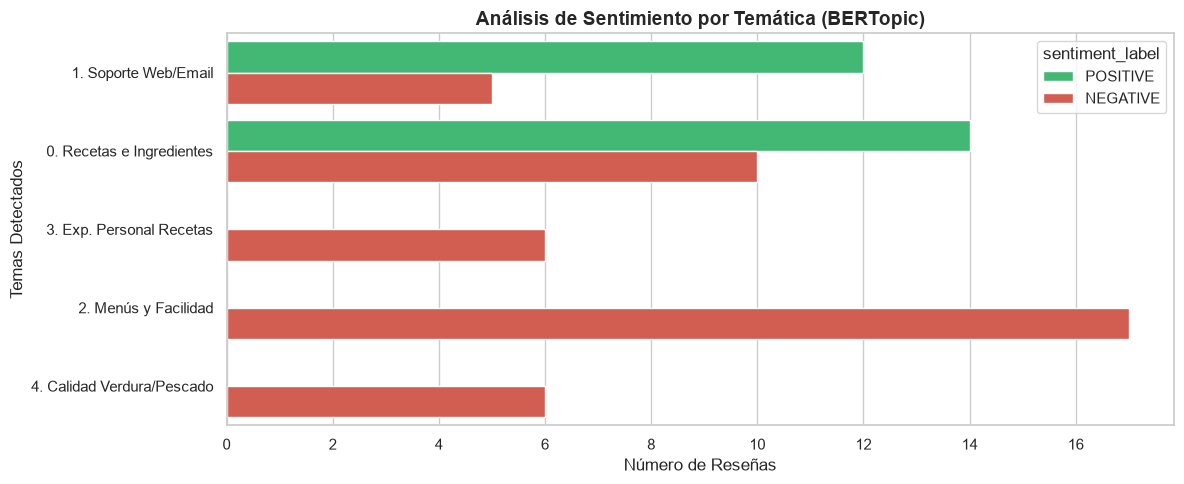

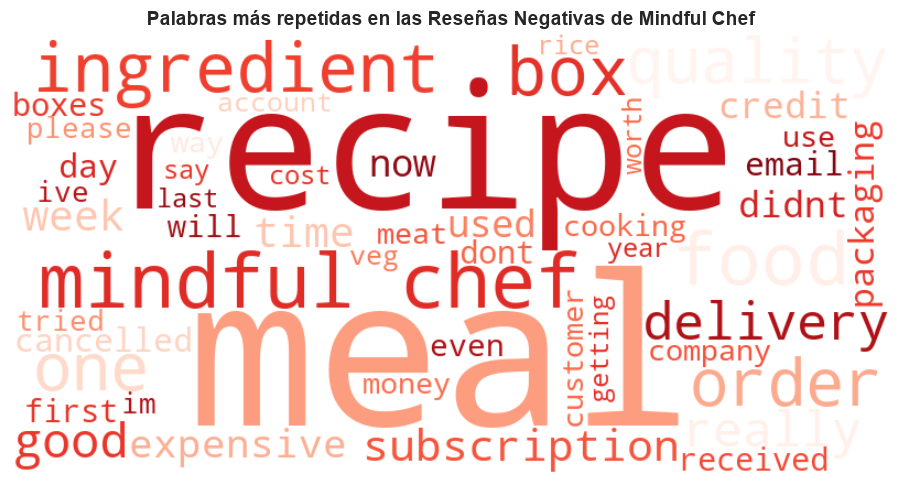

In [14]:
from wordcloud import WordCloud

# ==========================================
# GRAFICO 1: Sentimiento por Temas (BERTopic)
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

df_plot = df_target[df_target['bertopic_id'] != -1].copy()
topic_labels = {
    0: "0. Recetas e Ingredientes", 1: "1. Soporte Web/Email", 
    2: "2. Menús y Facilidad", 3: "3. Exp. Personal Recetas",
    4: "4. Calidad Verdura/Pescado", 5: "5. Cajas/Envíos Dañados"
}
df_plot['Topic_Name'] = df_plot['bertopic_id'].map(topic_labels)

sns.countplot(
    data=df_plot, y='Topic_Name', hue='sentiment_label', 
    palette={'POSITIVE': '#2ecc71', 'NEGATIVE': '#e74c3c'}
)
plt.title('Análisis de Sentimiento por Temática (BERTopic)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Reseñas')
plt.ylabel('Temas Detectados')
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# ==========================================
# GRAFICO 2: Nube de Palabras de las quejas (NEGATIVE)
# ==========================================
# Juntamos todos los textos limpios de las reseñas negativas
texto_negativo = " ".join(review for review in df_target[df_target['sentiment_label'] == 'NEGATIVE']['clean_review'])

# Configuramos y generamos la nube de palabras
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='Reds', # En tonos rojos para enfatizar que son quejas
    max_words=50
).generate(texto_negativo)

# Dibujamos la nube
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Quitamos los ejes para que quede limpio
plt.title('Palabras más repetidas en las Reseñas Negativas de Mindful Chef', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

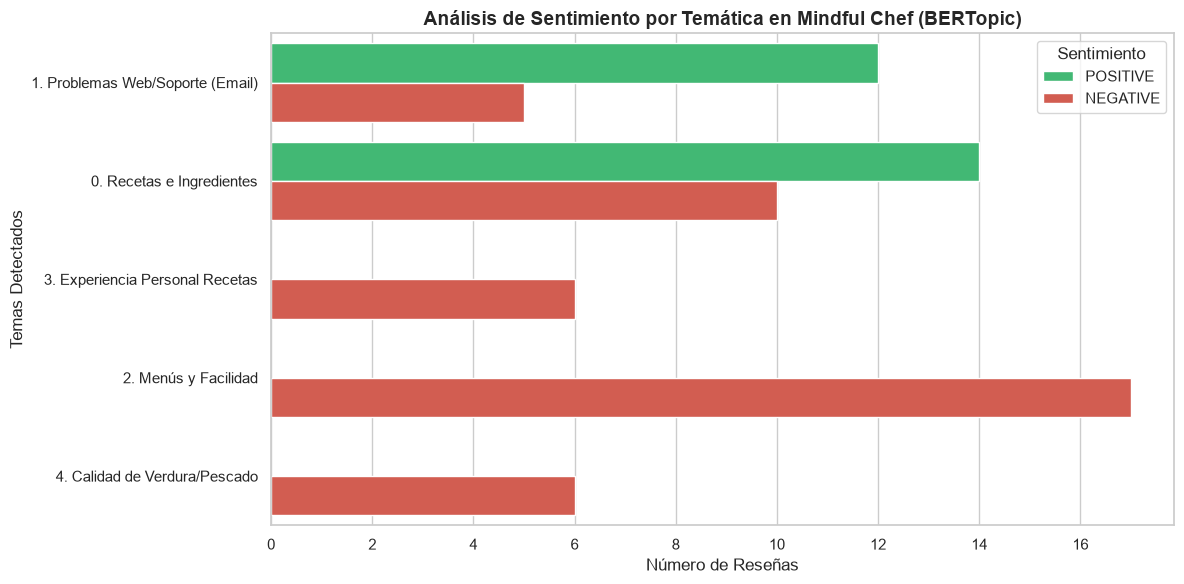

In [15]:
# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Creamos un gráfico de barras que cruza los Temas de BERTopic con el Sentimiento
# Filtramos el topic -1 para centrarnos en los temas concretos que descubrimos
df_plot = df_target[df_target['bertopic_id'] != -1].copy()

# Mapeamos los IDs de los temas a nombres más legibles basados en tus resultados
topic_labels = {
    0: "0. Recetas e Ingredientes",
    1: "1. Problemas Web/Soporte (Email)",
    2: "2. Menús y Facilidad",
    3: "3. Experiencia Personal Recetas",
    4: "4. Calidad de Verdura/Pescado",
    5: "5. Cajas/Envíos Dañados"
}
df_plot['Topic_Name'] = df_plot['bertopic_id'].map(topic_labels)

# 2. Dibujamos el gráfico de barras agrupado por Sentimiento
sns.countplot(
    data=df_plot, 
    y='Topic_Name', 
    hue='sentiment_label', 
    palette={'POSITIVE': '#2ecc71', 'NEGATIVE': '#e74c3c'}
)

plt.title('Análisis de Sentimiento por Temática en Mindful Chef (BERTopic)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Reseñas')
plt.ylabel('Temas Detectados')
plt.legend(title='Sentimiento')
plt.tight_layout()
plt.show()

### 9) Conclusiones del Análisis

Tras analizar los resultados del modelo de clasificación de sentimiento y la agrupación de temáticas mediante BERTopic sobre la muestra de Mindful Chef, se extraen las siguientes conclusiones:

* **Análisis de Sentimiento:** El modelo clasifica un **69% de las reseñas como negativas** y un **31% como positivas**. Al auditar los textos originales, se comprueba que el algoritmo funciona correctamente, ya que no detecta insultos o críticas vacías, sino feedback constructivo y detallado por parte de clientes insatisfechos.
* **Agrupación por Temáticas (BERTopic):** El modelo identifica que las quejas de los usuarios no son aleatorias, sino que se concentran en dos problemas operativos principales:
  1. **Gestión de Suscripciones (Tema 2):** Es el clúster con mayor volumen (17 reseñas). Los usuarios expresan dificultades y falta de flexibilidad a la hora de pausar, modificar menús o gestionar los pagos de las cajas.
  2. **Problemas Logísticos (Tema 5):** La nube de palabras complementa este punto mostrando que términos como *box*, *delivery* y *received* se asocian a retrasos en el reparto o productos que llegan dañados.
* **Puntos Fuertes:** El canal de **Soporte y Atención por Email (Tema 1)** muestra una clara tendencia **positiva** (12 reseñas). Esto indica que, aunque el servicio web o el reparto fallen, el equipo de atención al cliente resuelve las incidencias de manera eficaz cuando el usuario contacta con ellos.

**Recomendación:** Para mejorar la experiencia de cliente (CX), la estrategia de la empresa debería priorizar la optimización de la interfaz de usuario en la sección de gestión o cancelación de suscripciones de la app y revisar las condiciones de transporte con su proveedor logístico.